# Swin Transformer -- From Scratch

Complete implementation of the **Swin Transformer** (Liu et al., ICCV 2021) built from scratch in PyTorch.

Core components implemented:
1. **Window Partition / Reverse** -- split feature maps into local windows and merge them back
2. **Window Attention** -- multi-head self-attention with relative position bias
3. **Swin Block** -- W-MSA / SW-MSA + MLP with residual connections
4. **Patch Merging** -- spatial downsampling between stages
5. **Full 4-Stage Model** -- complete hierarchical vision transformer

## Imports

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR, LambdaLR
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import math
import numpy as np
import matplotlib.pyplot as plt

## Window Partition and Reverse

These handle the spatial manipulation at the core of Swin:
- `window_partition` splits a `(B, H, W, C)` feature map into `(B * nW, M, M, C)` non-overlapping windows
- `window_reverse` merges them back

The key insight is that attention is computed **independently within each window**, making it linear in image size instead of quadratic.

In [2]:
def window_partition(x, win_size):
    """
    Args:
        x: (B, H, W, C)
        win_size: window size M
    Returns:
        (B * num_windows, M, M, C)
    """
    B, H, W, C = x.shape
    x = x.view(B, H // win_size, win_size, W // win_size, win_size, C)
    x = x.permute(0, 1, 3, 2, 4, 5).contiguous()
    x = x.view(-1, win_size, win_size, C)
    return x


def window_reverse(windows, win_size, H, W):
    """
    Args:
        windows: (B * num_windows, ..., C)
        win_size: window size M
        H, W: original spatial dims
    Returns:
        (B, H, W, C)
    """
    nH, nW = H // win_size, W // win_size
    B = int(windows.shape[0] // (nH * nW))
    x = windows.view(B, nH, nW, win_size, win_size, -1)
    x = x.permute(0, 1, 3, 2, 4, 5).contiguous()
    x = x.view(B, H, W, -1)
    return x

## Window Attention

Multi-head self-attention applied within each window independently.

The attention formula:
```
Attention(Q, K, V) = softmax(Q K^T / sqrt(d) + B) V
```

Where `B` is the **relative position bias** -- a learnable table indexed by the pairwise relative positions `(delta_row, delta_col)` of tokens within the window.

Key implementation details:
- Fused QKV projection (`nn.Linear(dim, 3*dim)`) for efficiency
- Reshape into `(B_, num_heads, N, head_dim)` for multi-head computation
- Optional attention mask for shifted-window attention

In [3]:
class WindowAttention(nn.Module):
    def __init__(self, dim, num_heads, win_size, attn_drop=0., proj_drop=0.):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.win_size = win_size

        self.qkv = nn.Linear(dim, 3 * dim)
        self.proj = nn.Linear(dim, dim)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj_drop = nn.Dropout(proj_drop)

        # relative position bias
        coords = torch.stack(torch.meshgrid(
            torch.arange(win_size), torch.arange(win_size), indexing='ij'
        ))
        coords_flat = coords.flatten(1)
        rel = coords_flat[:, :, None] - coords_flat[:, None, :]
        rel = rel.permute(1, 2, 0).contiguous()
        rel[:, :, 0] += win_size - 1
        rel[:, :, 1] += win_size - 1
        rel[:, :, 0] *= 2 * win_size - 1
        self.register_buffer('rel_index', rel.sum(-1))

        self.rel_bias_table = nn.Parameter(
            torch.zeros((2 * win_size - 1) ** 2, num_heads)
        )
        nn.init.trunc_normal_(self.rel_bias_table, std=0.02)

    def forward(self, x, mask=None):
        B_, N, C = x.shape
        h, d = self.num_heads, self.head_dim

        qkv = self.qkv(x).reshape(B_, N, 3, h, d).permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)

        attn = (q * self.scale) @ k.transpose(-2, -1)

        bias = self.rel_bias_table[self.rel_index.view(-1)].view(N, N, -1)
        attn = attn + bias.permute(2, 0, 1).unsqueeze(0)

        if mask is not None:
            nW = mask.shape[0]
            attn = attn.view(B_ // nW, nW, h, N, N)
            attn = attn + mask.unsqueeze(1).unsqueeze(0)
            attn = attn.view(-1, h, N, N)

        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        out = (attn @ v).transpose(1, 2).reshape(B_, N, C)
        out = self.proj(out)
        out = self.proj_drop(out)
        return out

## Swin Block

Pre-Norm residual block:
```
Input (B, L, C)
  |
  +-- shortcut
  |
  v
LayerNorm -> reshape (B, H, W, C)
  v
[cyclic shift if SW-MSA]
  v
window_partition -> WindowAttention(+mask) -> window_reverse
  v
[reverse shift]
  v
+ shortcut
  |
  +-- shortcut
  v
LayerNorm -> MLP -> + shortcut
  v
Output (B, L, C)
```

Blocks alternate between W-MSA (shift=0) and SW-MSA (shift=M//2). The shifted variant creates cross-window connections by cyclically shifting the feature map before partitioning.

In [4]:
class SwinBlock(nn.Module):
    def __init__(self, dim, resolution, win_size, shift, num_heads,
                 mlp_ratio=4., drop=0., attn_drop=0.):
        super().__init__()
        self.resolution = resolution
        self.win_size = win_size
        # no shift if window covers the full spatial extent
        self.shift = shift if win_size < resolution[0] else 0

        self.norm1 = nn.LayerNorm(dim)
        self.attn = WindowAttention(dim, num_heads, win_size,
                                   attn_drop=attn_drop, proj_drop=drop)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, int(dim * mlp_ratio)),
            nn.GELU(),
            nn.Dropout(drop),
            nn.Linear(int(dim * mlp_ratio), dim),
            nn.Dropout(drop),
        )

        H, W = resolution
        if self.shift > 0:
            self.register_buffer('attn_mask', self._build_mask(H, W))
        else:
            self.attn_mask = None

    def _build_mask(self, H, W):
        ws, s = self.win_size, self.shift
        img_mask = torch.zeros(1, H, W, 1)
        rid = 0
        for h in (slice(0, -ws), slice(-ws, -s), slice(-s, None)):
            for w in (slice(0, -ws), slice(-ws, -s), slice(-s, None)):
                img_mask[:, h, w, :] = rid
                rid += 1
        wins = window_partition(img_mask, ws).view(-1, ws * ws)
        mask = wins.unsqueeze(1) - wins.unsqueeze(2)
        mask = mask.masked_fill(mask != 0, -100.0)
        return mask

    def forward(self, x):
        H, W = self.resolution
        B, L, C = x.shape

        shortcut = x
        x = self.norm1(x).view(B, H, W, C)

        if self.shift > 0:
            x = torch.roll(x, shifts=(-self.shift, -self.shift), dims=(1, 2))

        x_win = window_partition(x, self.win_size).view(-1, self.win_size**2, C)
        x_win = self.attn(x_win, mask=self.attn_mask)
        x = window_reverse(x_win, self.win_size, H, W)

        if self.shift > 0:
            x = torch.roll(x, shifts=(self.shift, self.shift), dims=(1, 2))

        x = shortcut + x.view(B, L, C)
        x = x + self.mlp(self.norm2(x))
        return x

## Patch Merging

Spatial downsampling between stages. Takes a 2x2 neighborhood of tokens, concatenates them along the channel dimension (4C), and projects down to 2C.

```
Stage 1: 16x16, C    -> PatchMerging -> 8x8,  2C
Stage 2:  8x8,  2C   -> PatchMerging -> 4x4,  4C
Stage 3:  4x4,  4C   -> PatchMerging -> 2x2,  8C
```

In [5]:
class PatchMerging(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.norm = nn.LayerNorm(4 * dim)
        self.reduction = nn.Linear(4 * dim, 2 * dim, bias=False)

    def forward(self, x, H, W):
        B, _, C = x.shape
        x = x.view(B, H, W, C)
        x0 = x[:, 0::2, 0::2, :]
        x1 = x[:, 1::2, 0::2, :]
        x2 = x[:, 0::2, 1::2, :]
        x3 = x[:, 1::2, 1::2, :]
        x = torch.cat([x0, x1, x2, x3], dim=-1).view(B, -1, 4 * C)
        x = self.norm(x)
        x = self.reduction(x)
        return x, H // 2, W // 2

## Patch Embedding and Swin Stage

In [6]:
class PatchEmbed(nn.Module):
    def __init__(self, in_channels=3, embed_dim=96, patch_size=4):
        super().__init__()
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        x = self.proj(x)
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)
        x = self.norm(x)
        return x, H, W


class SwinStage(nn.Module):
    def __init__(self, dim, resolution, depth, num_heads, win_size,
                 mlp_ratio=4., drop=0., attn_drop=0.):
        super().__init__()
        self.blocks = nn.ModuleList([
            SwinBlock(
                dim=dim, resolution=resolution, win_size=win_size,
                shift=0 if (i % 2 == 0) else win_size // 2,
                num_heads=num_heads, mlp_ratio=mlp_ratio,
                drop=drop, attn_drop=attn_drop,
            )
            for i in range(depth)
        ])

    def forward(self, x):
        for blk in self.blocks:
            x = blk(x)
        return x

## Full 4-Stage Swin Transformer

The complete model, configured for 32x32 input:

```
32x32 image
    |
PatchEmbed (2x2, stride 2)
    v
256 tokens, 64ch         16x16, win=4
    |
Stage 1: 2 blocks (W-MSA, SW-MSA)
    |
PatchMerging
    v
64 tokens, 128ch          8x8, win=4
    |
Stage 2: 2 blocks
    |
PatchMerging
    v
16 tokens, 256ch          4x4, win=4
    |
Stage 3: 6 blocks
    |
PatchMerging
    v
4 tokens, 512ch           2x2, win=2 (no shift)
    |
Stage 4: 2 blocks
    |
LayerNorm -> GAP -> Linear(512, num_classes)
```

In [7]:
class SwinTransformer(nn.Module):
    def __init__(self, in_channels=3, num_classes=10, patch_size=2,
                 embed_dim=64, depths=(2, 2, 6, 2), num_heads=(2, 4, 8, 16),
                 window_size=4, img_size=32, mlp_ratio=4.,
                 drop_rate=0.1, attn_drop_rate=0.):
        super().__init__()
        self.num_stages = len(depths)
        self.patch_embed = PatchEmbed(in_channels, embed_dim, patch_size)
        grid = img_size // patch_size

        self.stages = nn.ModuleList()
        self.downsamples = nn.ModuleList()

        for i in range(self.num_stages):
            dim_i = embed_dim * (2 ** i)
            res_i = grid // (2 ** i)
            ws_i = min(window_size, res_i)

            self.stages.append(SwinStage(
                dim=dim_i, resolution=(res_i, res_i), depth=depths[i],
                num_heads=num_heads[i], win_size=ws_i,
                mlp_ratio=mlp_ratio, drop=drop_rate, attn_drop=attn_drop_rate,
            ))
            if i < self.num_stages - 1:
                self.downsamples.append(PatchMerging(dim_i))
            else:
                self.downsamples.append(nn.Identity())

        final_dim = embed_dim * (2 ** (self.num_stages - 1))
        self.norm = nn.LayerNorm(final_dim)
        self.head_drop = nn.Dropout(drop_rate)
        self.head = nn.Linear(final_dim, num_classes)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x, H, W = self.patch_embed(x)
        for i in range(self.num_stages):
            x = self.stages[i](x)
            if i < self.num_stages - 1:
                x, H, W = self.downsamples[i](x, H, W)
        x = self.norm(x)
        x = x.mean(dim=1)
        x = self.head_drop(x)
        x = self.head(x)
        return x

## Shape Verification

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

model = SwinTransformer().to(device)
dummy = torch.randn(2, 3, 32, 32, device=device)
out = model(dummy)

print(f"Input:  {dummy.shape}")
print(f"Output: {out.shape}")
print(f"Params: {sum(p.numel() for p in model.parameters()):,}")

Device: cuda
Input:  torch.Size([2, 3, 32, 32])
Output: torch.Size([2, 10])
Params: 12,241,894


---

## Training

Transformer-specific training considerations used here:

- **LR warmup** -- critical for stable transformer training. The first few epochs linearly ramp up the learning rate from near-zero to the target LR. Without this, transformers often fail to converge.
- **Cosine annealing** -- after warmup, decay the LR smoothly following a cosine schedule.
- **AdamW** -- decoupled weight decay. Bias and LayerNorm parameters are excluded from weight decay.
- **Gradient clipping** -- prevents exploding gradients, especially in early training.
- **Dropout** (0.1) in MLP and after attention projection for regularization.

In [9]:
# -- Dataset --
# Swap this section for any dataset you want to experiment with.

MEAN = (0.4914, 0.4822, 0.4465)
STD  = (0.2470, 0.2435, 0.2616)

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_data = datasets.CIFAR10('./data', train=True,  download=True, transform=transform_train)
test_data  = datasets.CIFAR10('./data', train=False, download=True, transform=transform_test)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_data,  batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_data)}, Test: {len(test_data)}")

100%|██████████| 170M/170M [00:04<00:00, 35.3MB/s]


Train: 50000, Test: 10000


In [10]:
# -- Model + Optimizer --

model = SwinTransformer(
    in_channels=3,
    num_classes=10,
    patch_size=2,
    embed_dim=64,
    depths=(2, 2, 6, 2),
    num_heads=(2, 4, 8, 16),
    window_size=4,
    img_size=32,
    drop_rate=0.1,
).to(device)

# separate params: no weight decay on bias and layernorm
decay_params = []
no_decay_params = []
for name, p in model.named_parameters():
    if p.requires_grad:
        if 'bias' in name or 'norm' in name:
            no_decay_params.append(p)
        else:
            decay_params.append(p)

optimizer = optim.AdamW([
    {'params': decay_params, 'weight_decay': 0.05},
    {'params': no_decay_params, 'weight_decay': 0.0},
], lr=1e-3)

# warmup + cosine schedule
NUM_EPOCHS = 50
WARMUP_EPOCHS = 5

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(1, NUM_EPOCHS - WARMUP_EPOCHS)
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = LambdaLR(optimizer, lr_lambda)
loss_fn = nn.CrossEntropyLoss()

num_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {num_params:,}")
print(f"Epochs: {NUM_EPOCHS}, Warmup: {WARMUP_EPOCHS}")

Parameters: 12,241,894
Epochs: 50, Warmup: 5


In [11]:
# -- Training loop --

def evaluate(model, loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for img, label in loader:
            img, label = img.to(device), label.to(device)
            pred = model(img).argmax(dim=1)
            correct += pred.eq(label).sum().item()
            total += label.size(0)
    return correct / total


for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    correct = total = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    for img, label in pbar:
        img, label = img.to(device), label.to(device)

        output = model(img)
        loss = loss_fn(output, label)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        running_loss += loss.item()
        correct += output.argmax(1).eq(label).sum().item()
        total += label.size(0)
        pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{100.*correct/total:.1f}%")

    scheduler.step()
    test_acc = evaluate(model, test_loader)
    lr = optimizer.param_groups[0]['lr']

    print(
        f"Epoch {epoch+1:>2}/{NUM_EPOCHS} | "
        f"Loss: {running_loss/len(train_loader):.4f} | "
        f"Train: {100.*correct/total:.2f}% | "
        f"Test: {100.*test_acc:.2f}% | "
        f"LR: {lr:.6f}"
    )

Epoch 1/50: 100%|██████████| 391/391 [00:36<00:00, 10.86it/s, acc=33.4%, loss=1.5845]


Epoch  1/50 | Loss: 1.8052 | Train: 33.38% | Test: 40.24% | LR: 0.000400


Epoch 2/50: 100%|██████████| 391/391 [00:35<00:00, 10.93it/s, acc=42.0%, loss=1.4204]


Epoch  2/50 | Loss: 1.5840 | Train: 41.96% | Test: 44.23% | LR: 0.000600


Epoch 3/50: 100%|██████████| 391/391 [00:35<00:00, 11.17it/s, acc=46.8%, loss=1.3846]


...

Epoch 48/50 | Loss: 0.4836 | Train: 82.68% | Test: 77.98% | LR: 0.000005


Epoch 49/50: 100%|██████████| 391/391 [00:35<00:00, 10.90it/s, acc=82.7%, loss=0.5925]


Epoch 49/50 | Loss: 0.4821 | Train: 82.73% | Test: 77.79% | LR: 0.000001


Epoch 50/50: 100%|██████████| 391/391 [00:35<00:00, 10.93it/s, acc=82.9%, loss=0.5089]


Epoch 50/50 | Loss: 0.4797 | Train: 82.88% | Test: 77.75% | LR: 0.000000


---

## Evaluation

### Per-Class Accuracy

In [12]:
CLASSES = ('airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

model.eval()
class_correct = [0] * 10
class_total = [0] * 10

all_preds = []
all_labels = []

with torch.no_grad():
    for img, label in test_loader:
        img, label = img.to(device), label.to(device)
        pred = model(img).argmax(dim=1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(label.cpu().numpy())
        for i in range(label.size(0)):
            c = label[i].item()
            class_total[c] += 1
            class_correct[c] += (pred[i] == label[i]).item()

print(f"{'Class':<12} {'Correct':>8} {'Total':>6} {'Accuracy':>9}")
print('-' * 38)
for i in range(10):
    acc = 100. * class_correct[i] / class_total[i]
    print(f"{CLASSES[i]:<12} {class_correct[i]:>8} {class_total[i]:>6} {acc:>8.2f}%")
print('-' * 38)
overall = 100. * sum(class_correct) / sum(class_total)
print(f"{'Overall':<12} {sum(class_correct):>8} {sum(class_total):>6} {overall:>8.2f}%")

Class         Correct  Total  Accuracy
--------------------------------------
airplane          807   1000    80.70%
automobile        873   1000    87.30%
bird              720   1000    72.00%
cat               600   1000    60.00%
deer              747   1000    74.70%
dog               671   1000    67.10%
frog              824   1000    82.40%
horse             797   1000    79.70%
ship              866   1000    86.60%
truck             870   1000    87.00%
--------------------------------------
Overall          7775  10000    77.75%


### Confusion Matrix

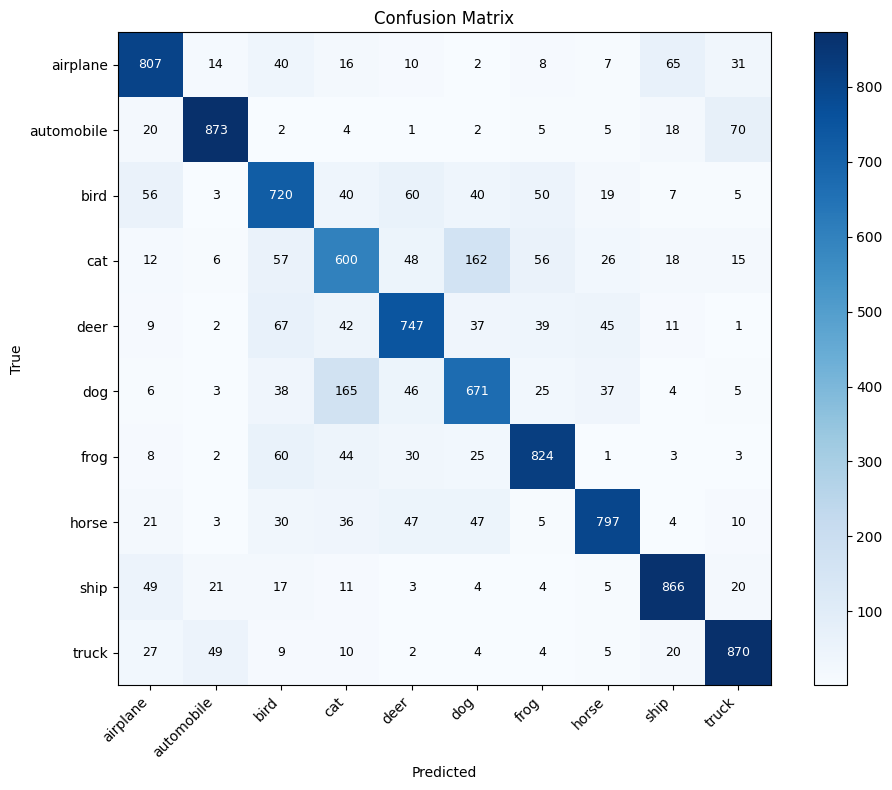

In [14]:
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# build confusion matrix
cm = np.zeros((10, 10), dtype=int)
for t, p in zip(all_labels, all_preds):
    cm[t, p] += 1

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(CLASSES, rotation=45, ha='right')
ax.set_yticklabels(CLASSES)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix')

# annotate cells
for i in range(10):
    for j in range(10):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', color=color, fontsize=9)

plt.colorbar(im)
plt.tight_layout()
plt.show()

### Sample Predictions

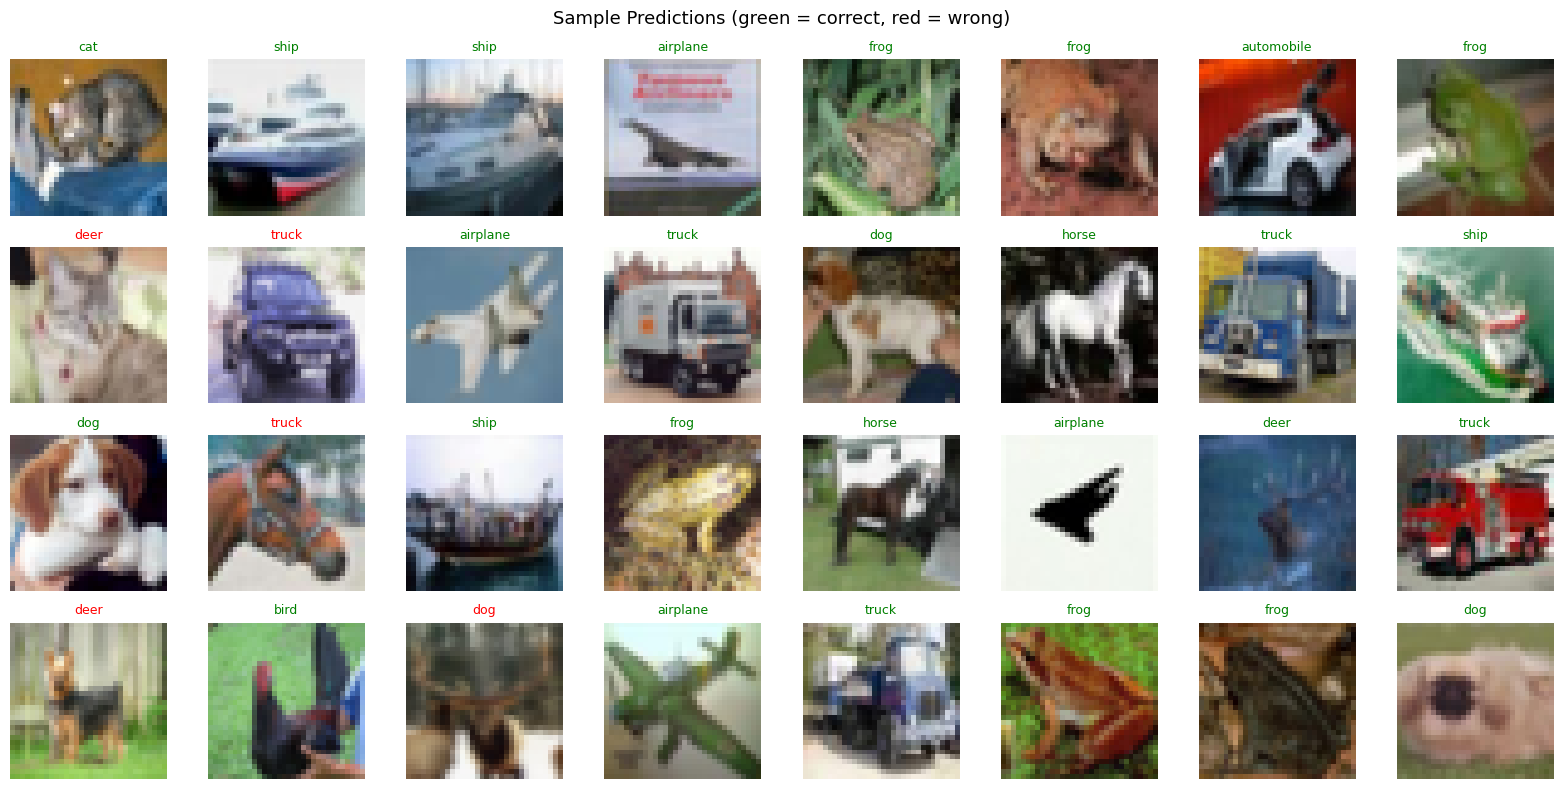

In [15]:
def denormalize(img, mean, std):
    for c in range(3):
        img[c] = img[c] * std[c] + mean[c]
    return img.clamp(0, 1)

model.eval()
test_iter = iter(test_loader)
images, labels = next(test_iter)
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    preds = model(images).argmax(dim=1)

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    img = denormalize(images[i].cpu().clone(), MEAN, STD)
    ax.imshow(img.permute(1, 2, 0).numpy())
    true_label = CLASSES[labels[i]]
    pred_label = CLASSES[preds[i]]
    color = 'green' if preds[i] == labels[i] else 'red'
    ax.set_title(f"{pred_label}", color=color, fontsize=9)
    ax.axis('off')

plt.suptitle('Sample Predictions (green = correct, red = wrong)', fontsize=13)
plt.tight_layout()
plt.show()

### Test on a Single Image

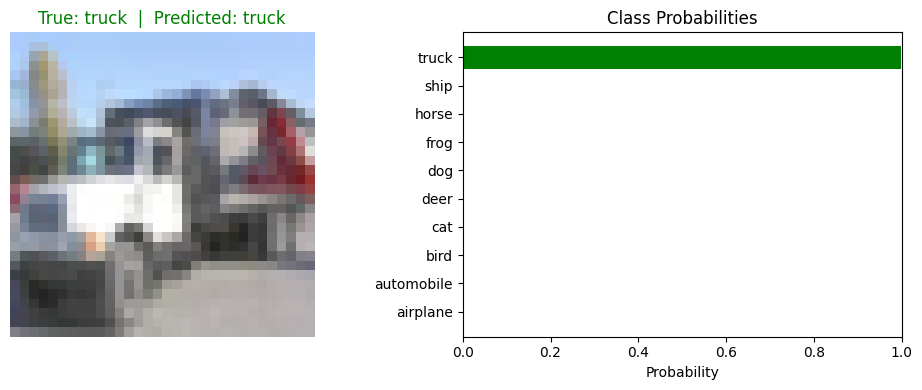

In [20]:
# pick a random test image and predict
idx = torch.randint(len(test_data), (1,)).item()
img, label = test_data[idx]

model.eval()
with torch.no_grad():
    logits = model(img.unsqueeze(0).to(device))
    probs = torch.softmax(logits, dim=1).squeeze()

pred_class = probs.argmax().item()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# show image
display_img = denormalize(img.clone(), MEAN, STD)
ax1.imshow(display_img.permute(1, 2, 0).numpy())
ax1.set_title(f'True: {CLASSES[label]}  |  Predicted: {CLASSES[pred_class]}',
              color='green' if pred_class == label else 'red')
ax1.axis('off')

# show class probabilities
colors = ['green' if i == label else 'steelblue' for i in range(10)]
ax2.barh(range(10), probs.cpu().numpy(), color=colors)
ax2.set_yticks(range(10))
ax2.set_yticklabels(CLASSES)
ax2.set_xlabel('Probability')
ax2.set_title('Class Probabilities')
ax2.set_xlim(0, 1)

plt.tight_layout()
plt.show()